In [ ]:
from solver_selection_thm.thm_physics import ModelTHM, initialize, run, params
from solver_selection_thm.selector import SolverSelector
from solver_selection_thm.solver_space import CategoricalChoices, NumericalChoices
from solver_selection_thm.performance_predictor import (
    PerformancePredictorPassiveAgressive,
    PerformancePredictorEpsGreedy,
    RewardEstimator,
)
from solver_selection_thm.solver_space import SolverSpace
from solver_selection_thm.pp_binding import (
    KNOWN_SOLVER_COMPONENTS_THM,
    SolverSelectionMixinTHM,
)
from thm_runscript import make_solver_space_scheme_fthm
import numpy as np
from matplotlib import pyplot as plt
from load_experiments_data import load_experiments_data_spe

/home/porepy/porepy/src/porepy/utils/ui_and_logging.py:45: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange as progressbar_class  # type: ignore


In [ ]:
RUNS = [30, 31, 32, 33, 34]
RUNS = [40, 41, 42, 43, 44]

RUNS_RANDOM = [30, 31, 32, 33, 34]

sim_data, perf_data, solver_selector = load_experiments_data_spe(runs=RUNS, random_selection=False)
sim_data_random, perf_data_random, solver_selector = load_experiments_data_spe(runs=RUNS_RANDOM, random_selection=True)

Num solvers: 1095
Num solvers: 1095
Num solvers: 1095
Num solvers: 1095
Num solvers: 1095
Num solvers: 1095
Num solvers: 1095
Num solvers: 1095
Num solvers: 1095
Num solvers: 1095


In [ ]:
from collections import defaultdict
import pandas as pd


def make_pandas(sim_data, perf_data, seq_ids):
    sim_data_dict = defaultdict(lambda: [])
    perf_data_dict = defaultdict(lambda: [])
    i = 0
    for seq_id, data_simulations, solver_selection_history_seq in zip(
        seq_ids, sim_data, perf_data
    ):
        sim_idx = -1
        for data_row in data_simulations:
            for data in data_row:
                sim_idx += 1

                for ts_idx, ts in enumerate(data):
                    for ls_idx, ls in enumerate(ts.linear_solves):
                        sim_data_dict["seq_id"].append(seq_id)
                        sim_data_dict["sim_idx"].append(sim_idx)
                        sim_data_dict["ts_idx"].append(ts_idx)
                        sim_data_dict["ls_idx"].append(ls_idx)
                        sim_data_dict["real_solve_time"].append(ls.linear_solve_time)
                        sim_data_dict["krylov_iters"].append(ls.krylov_iters)
                        sim_data_dict["petsc_converged_reason"].append(
                            ls.petsc_converged_reason
                        )
                        sim_data_dict["cfl"].append(ls.cfl)

        solver_selection_history = None
        for x in solver_selection_history_seq:
            if x is not None:
                solver_selection_history = x

        for reward_idx in range(len(solver_selection_history.reward)):
            # if solver_selection_history.features[reward_idx][5] > 1e10 or solver_selection_history.features[reward_idx][4] > 1e10:
            #     i += 1
            #     print('dropping large', i)
            #     continue
            perf_data_dict["seq_id"].append(seq_id)
            perf_data_dict["sim_idx"].append(sim_idx)
            perf_data_dict["reward"].append(
                solver_selection_history.reward[reward_idx]
            )
            perf_data_dict["expectation"].append(
                solver_selection_history.expectation[reward_idx]
            )
            perf_data_dict["decision_idx"].append(
                solver_selection_history.decision_idx[reward_idx]
            )
            perf_data_dict["features"].append(
                solver_selection_history.features[reward_idx]
            )
    return pd.DataFrame(data=sim_data_dict), pd.DataFrame(data=perf_data_dict)


ALL_RUNS = [str(x) for x in RUNS] + [f"R{x}" for x in RUNS_RANDOM]

df_sim, df_perf = make_pandas(
    sim_data=sim_data + sim_data_random,
    perf_data=perf_data + perf_data_random,
    seq_ids=ALL_RUNS,
)
df_sim

,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl
0,40,0,0,0,1.406330,22,2,2.201971e-14
1,40,0,0,1,1.550895,21,2,5.919609e-01
2,40,0,0,2,12.868275,18,2,5.709300e-01
3,40,0,0,3,1.294775,17,2,5.710351e-01
4,40,0,0,4,15.096113,16,2,5.710357e-01
...,...,...,...,...,...,...,...,...
25245,R34,14,50,1,1.400280,18,2,4.719660e+04
25246,R34,14,50,2,6.997320,19,2,4.719660e+04
25247,R34,14,51,0,4.559548,15,2,2.649556e+04
25248,R34,14,51,1,1.345384,20,2,2.649556e+04


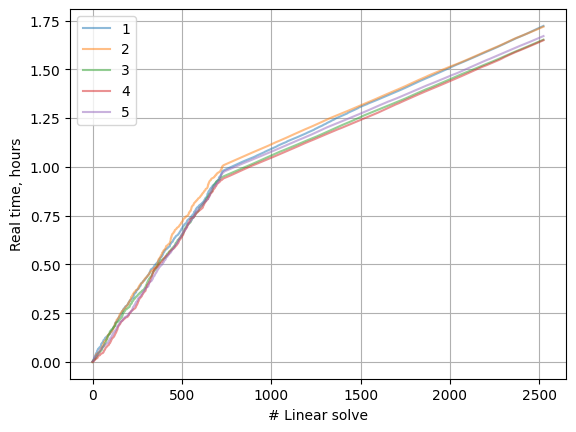

In [ ]:
FAIL_REWARD = -100
HOUR = 60 * 60
DAY = 24 * HOUR

labels = [1,2,3,4,5]
for i, seq_id in enumerate(ALL_RUNS[:5]):
    seq_idx = np.array(df_sim.seq_id == seq_id)
    time = np.array(df_sim.real_solve_time)[seq_idx]
    plt.plot(np.cumsum(time) / HOUR, label=labels[i], alpha=0.5)
    # plt.plot(np.cumsum(time) / HOUR, alpha=0.5, label=seq_id)
plt.legend()
plt.ylabel('Real time, hours')
plt.xlabel('# Linear solve')
plt.grid()
plt.savefig('spe_runtime.png')

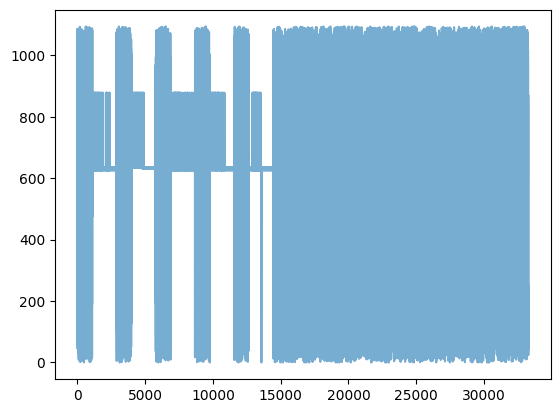

In [ ]:
decision_id = np.array(df_perf.decision_idx)
_ = plt.plot(decision_id, label='Decision idx', alpha=0.6)

The number of successful solves is 3962, both for real and random.
This is because Random fails more, but proceeds only after success. And it needs to solve exactly this number of linear systems.

1095


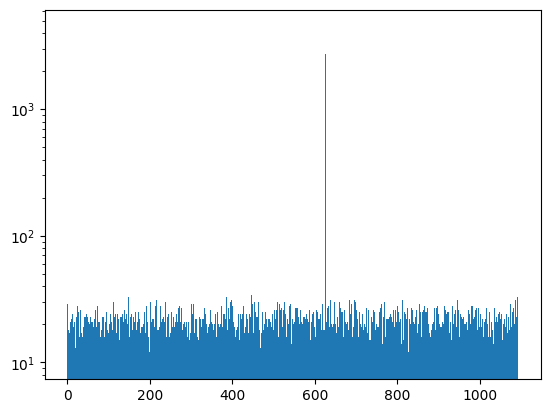

In [ ]:
num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]
print(num_solvers)
_ = plt.hist(decision_id, bins=num_solvers, log=True)

In [ ]:
FAIL_REWARD = -100
num_success = (df_perf.reward > FAIL_REWARD).sum()
print(num_success, df_perf.shape[0])
print(num_success / df_perf.shape[0])

25235 33268
0.7585367319947096


In [ ]:
X = np.stack(df_perf.features)
X = np.clip(X, -1e10, 1e10)
y = np.array(df_perf.reward)
success = y > FAIL_REWARD
Xsuccess = X[success]
ysuccess = y[success]
ycat = success
print(Xsuccess.shape, ysuccess.shape)

(25235, 36) (25235,)


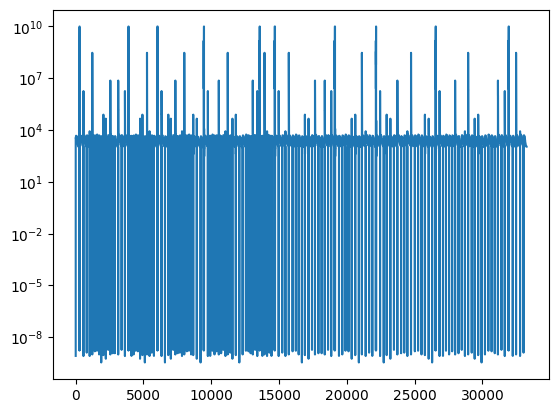

In [ ]:
plt.plot(abs(X)[:, 5])
plt.yscale('log')

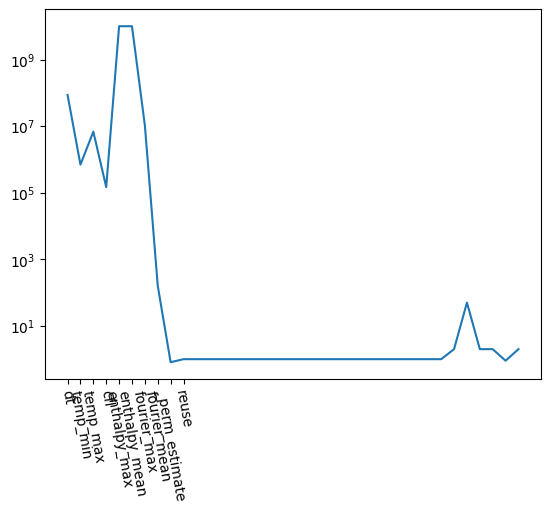

In [ ]:
plt.yscale("log")
plt.plot(abs(X).max(axis=0))

features = [
    "dt",
    "temp_min",
    "temp_max",
    "cfl",
    "enthalpy_max",
    "enthalpy_mean",
    "fourier_max",
    "fourier_mean",
    "_perm_estimate",
    "reuse",
]
_ = plt.xticks(range(len(features)), features, rotation=-80)

In [ ]:
from typing import Literal

classification_case: Literal["all", "one_seq", "random"] = "all"
if classification_case == "all":
    X_classification = X
    y_classification = ycat
elif classification_case == "one_seq":
    filter_ = np.array((df_perf.seq_id == "32"))
    X_classification = X[filter_]
    y_classification = ycat[filter_]
elif classification_case == "random":
    filter_ = np.array((df_perf.seq_id == "R32"))
    X_classification = X[filter_]
    y_classification = ycat[filter_]
else:
    raise ValueError(classification_case)

print(f"{classification_case = }", X_classification.shape, y_classification.shape)
print('success %:', y_classification.sum() / y_classification.size * 100)

classification_case = 'all' (33268, 36) (33268,)
success %: 75.85367319947096


In [ ]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.linear_model import SGDClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils.class_weight import compute_class_weight
from solver_selection_thm.performance_predictor import SuccessClassifier


classifier = SuccessClassifier()

scoring = ("accuracy", "f1")
cv_results = cross_validate(
    classifier,
    X_classification,
    y_classification,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
    n_jobs=-1,
)
for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

best_classifier_offline = cv_results["estimator"][np.argmax(cv_results["test_f1"])]
best_classifier_offline

accuracy
Train scores: [0.99872248 0.99947396 0.9988352  0.99898553 0.9987601 ]
Test scores: [0.99909829 0.99939886 0.99909829 0.9981963  0.99909815]
Mean Train: 0.9989554539292691
Mean Test: 0.9989779769898897

f1
Train scores: [0.99915725 0.99965317 0.99923254 0.99933087 0.99918205]
Test scores: [0.99940523 0.99960372 0.99940582 0.99880976 0.99940523]
Mean Train: 0.9993111775607453
Mean Test: 0.9993259551542536



SuccessClassifier()

2. Training offline model with cross-validation and comparing its

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import KFold

def make_oracle_regressor():
    return GradientBoostingRegressor(random_state=42)
    # return RewardRegressor()
oracle = make_oracle_regressor()

scoring = ("r2", "neg_mean_absolute_error", "neg_mean_squared_error")
cv_results = cross_validate(
    oracle,
    Xsuccess,
    ysuccess,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=scoring,
    return_train_score=True,
    return_estimator=True,
    n_jobs=-1,
)

In [ ]:
for score in scoring:
    print(score)
    print("Train scores:", cv_results[f"train_{score}"])
    print("Test scores:", cv_results[f"test_{score}"])
    print("Mean Train:", np.mean(cv_results[f"train_{score}"]))
    print("Mean Test:", np.mean(cv_results[f"test_{score}"]))
    print()

best_regressor_offline = cv_results["estimator"][np.argmax(cv_results["test_r2"])]
best_regressor_offline

r2
Train scores: [0.89994965 0.8944983  0.89300621 0.89457565 0.90353122]
Test scores: [0.88686864 0.88784426 0.8975341  0.88958137 0.89483889]
Mean Train: 0.8971122048691422
Mean Test: 0.8913334531737334

neg_mean_absolute_error
Train scores: [-0.05010445 -0.05071009 -0.05138706 -0.0506339  -0.04907595]
Test scores: [-0.05034652 -0.05306859 -0.05086656 -0.05243388 -0.04970992]
Mean Train: -0.05038228832344212
Mean Test: -0.051285095823659796

neg_mean_squared_error
Train scores: [-0.00578611 -0.00593963 -0.00609907 -0.00591412 -0.00559505]
Test scores: [-0.00609595 -0.00672717 -0.00586277 -0.00671537 -0.00559619]
Mean Train: -0.005866794647759945
Mean Test: -0.006199491210176843



,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
np.std(ysuccess)

0.2388469828070277

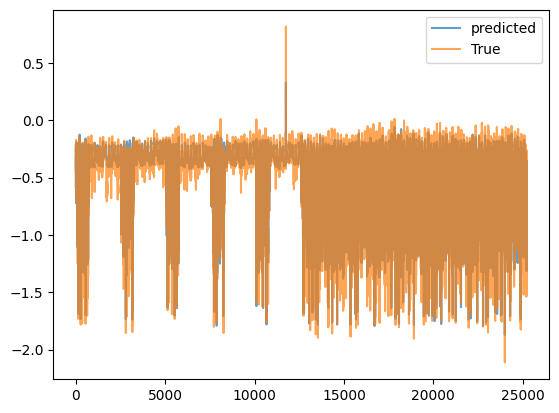

In [ ]:
plt.plot(best_regressor_offline.predict(Xsuccess), label='predicted', alpha=0.7)
plt.plot(ysuccess, label='True', alpha=0.7)
plt.legend()

Offline ranking score

In [ ]:
from typing import Literal

ranking_case: Literal["all", "one_seq", "random"] = "one_seq"
if ranking_case == "all":
    X_ranking = Xsuccess
    y_ranking = ysuccess
elif ranking_case == "one_seq":
    filter_ = np.array((df_perf.seq_id == "32") & (df_perf.reward > FAIL_REWARD))
    X_ranking = X[filter_]
    y_ranking = y[filter_]
    X_dataset1 = X_ranking
elif ranking_case == "random":
    filter_ = np.array(
        (
            (df_perf.seq_id == "R30")
            | (df_perf.seq_id == "R31")
            | (df_perf.seq_id == "R32")
            | (df_perf.seq_id == "R33")
            | (df_perf.seq_id == "R34")
        )
        & (df_perf.reward > FAIL_REWARD)
    )
    X_ranking = X[filter_]
    y_ranking = y[filter_]
    X_dataset2 = X_ranking
else:
    raise ValueError(ranking_case)

print(f"{ranking_case = }", X_ranking.shape, y_ranking.shape)

ranking_case = 'one_seq' (2523, 36) (2523,)


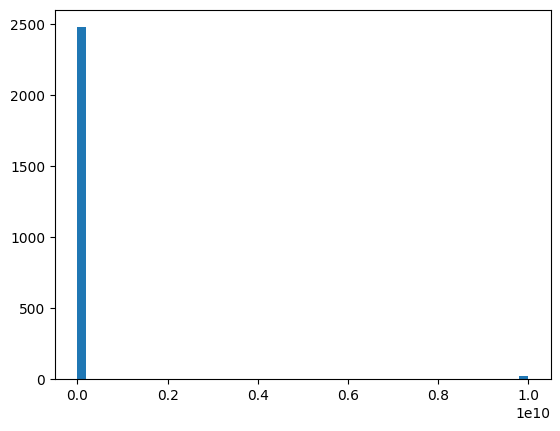

In [ ]:
features = [
    "dt",
    "temp_min",
    "temp_max",
    "cfl",
    "enthalpy_max",
    "enthalpy_mean",
    "fourier_max",
    "fourier_mean",
    "_perm_estimate",
    "reuse",
]

# X_ranking[:, 1] = X_ranking[:, 1].clip(-10, 1000)
# X_ranking[:, 2] = X_ranking[:, 2].clip(-10, 1000)
# X_ranking[:, 4] = X_ranking[:, 4].clip(0, 1e4)
# X_ranking[:, 5] = X_ranking[:, 5].clip(0, 1e4)

# X_ranking[:, 4] = np.log(X_ranking[:, 4])
# X_ranking[:, 5] = np.log(X_ranking[:, 5])

# Xsuccess[:, 4] = Xsuccess[:, 4].clip(0, 1e4)
# Xsuccess[:, 5] = Xsuccess[:, 5].clip(0, 1e4)


data = X_ranking[:, 4]
_ = plt.hist(data, bins=50)

# data = abs(data)
# bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 50)
# plt.hist(data, bins=bins)
# plt.xscale('log')

In [ ]:
oracle = make_oracle_regressor()
oracle.fit(Xsuccess, ysuccess)  # oracle trains on full data anyway

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [ ]:
from sklearn.model_selection import KFold
from solver_selection_thm.performance_predictor import RewardRegressor
from tqdm import tqdm

def stack_features_solvers(features: np.ndarray, solvers: np.ndarray) -> np.ndarray:
    dim0 = solvers.shape[0]
    dim1 = features.shape[0]
    features = np.broadcast_to(features, (dim0, dim1))
    return np.concatenate([features, solvers], axis=1)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

all_solvers = solver_selector.solver_space.all_decisions_encoding#[success_atleast_once]
Xranking_features = X_ranking[:, : -all_solvers.shape[1]]  # removing solvers encoding

data_k_fold = []

for train_set, test_set in kf.split(X_ranking):
    estimator = RewardRegressor()
    # estimator = make_oracle_regressor()
    estimator.fit(X_ranking[train_set], ysuccess[train_set])

    data_this = []
    data_k_fold.append(data_this)

    # ranking
    for test_idx in tqdm(test_set):
        x_to_predict = stack_features_solvers(Xranking_features[test_idx], all_solvers)

        # online
        ypred = estimator.predict(x_to_predict)

        # offline
        yoracle = oracle.predict(x_to_predict)

        data_this.append({'yoracle': yoracle, 'ypred': ypred})

100%|██████████| 504/504 [00:00<00:00, 954.92it/s]


In [ ]:
X_ranking[train_set].shape

(2019, 36)

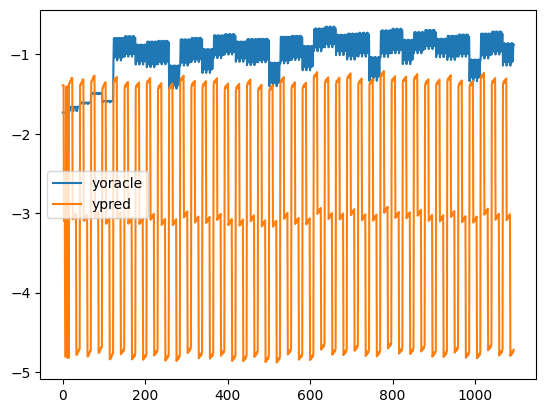

In [ ]:
plt.plot(data_k_fold[0][-10]['yoracle'], label='yoracle')
plt.plot(data_k_fold[1][-10]['ypred'], label='ypred')
plt.legend()

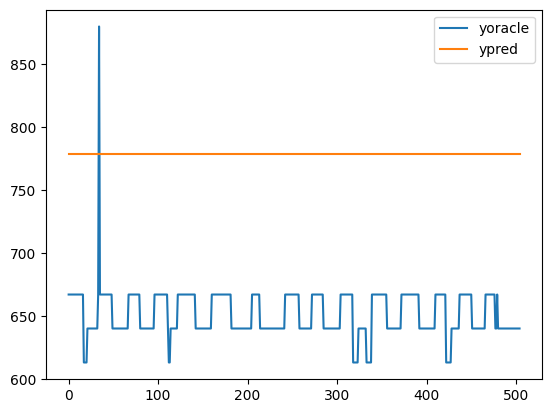

In [ ]:
plt.plot([np.argmax(x['yoracle']) for x in data_k_fold[2]], label='yoracle')
plt.plot([np.argmax(x['ypred']) for x in data_k_fold[2]], label='ypred')
plt.legend()
# [np.argmax(x['ypred']) for x in data_k_fold[2]]

In [ ]:
def top_1_normalized_score(ypred, ytrue):
    i = np.argmax(ypred)
    s = ytrue[i]
    ymin, ymax = np.min(ytrue), np.max(ytrue)
    if ymax == ymin:
        return 0.0  # degenerate case: all ytrue values are equal
    else:
        return -1.0 + 2.0 * (s - ymin) / (ymax - ymin)
    
def top_eps_accuracy(ypred, ytrue, eps=1e-3):
    i = np.argmax(ypred)
    return abs(ytrue[i] - np.max(ytrue)) <= eps

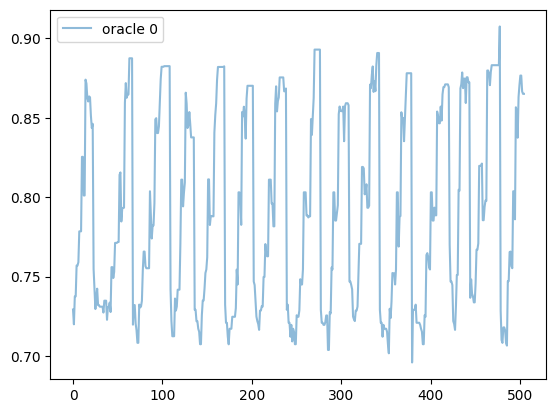

In [ ]:
a = [[top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_test] for data_test in data_k_fold]
b = [[np.max(x['ypred']) for x in data_test] for data_test in data_k_fold]

for i, (aa, bb) in enumerate(zip(a, b[:1])):
    plt.plot(aa, label=f'oracle {i}', alpha=0.5)
    # plt.plot(bb, label=f'pred {i}', alpha=0.5)

# plt.ylim(-1, 0)
plt.legend()

In [ ]:
mean_NTS = [np.mean([top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_test]) for data_test in data_k_fold]
print(mean_NTS)
np.mean(mean_NTS)

[0.7929804485397606, 0.790966101498087, 0.787484248125301, 0.7932657432956203, 0.794954224467808]


0.7919301531853153

In [ ]:
for eps in [1e-2, 3e-2, 4e-2, 1e-1, 3e-1, 4e-1]:
    mean_topeps = [np.mean([top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_test]) for data_test in data_k_fold]
    mean_topeps = np.mean(mean_topeps)
    print(f'{eps = :.0e}, {mean_topeps = :.2f}')

eps = 1e-02, mean_topeps = 0.00
eps = 3e-02, mean_topeps = 0.00
eps = 4e-02, mean_topeps = 0.00
eps = 1e-01, mean_topeps = 0.36
eps = 3e-01, mean_topeps = 1.00
eps = 4e-01, mean_topeps = 1.00


Incremental learning

In [ ]:
class TwoEstimators:

    def __init__(self, classifier, regressor):
        self.classifier = classifier
        self.regressor = regressor

    def fit(self, X, y):
        success = y >= FAIL_REWARD
        self.classifier.fit(X, success)
        self.regressor.fit(X[success], y[success])

    def partial_fit(self, X, y):
        X = np.array(X).reshape(1, -1)
        y = np.atleast_1d(y)
        success = y >= FAIL_REWARD
        self.classifier.partial_fit(X, success)
        if success:
            self.regressor.partial_fit(X[success], y[success])

    def predict(self, X):
        reward_estimate = np.full(X.shape[0], FAIL_REWARD, dtype=float)
        success_estimate = self.classifier.predict(X)
        if not np.any(success_estimate):
            return success_estimate, reward_estimate

        reward_estimate[success_estimate] = self.regressor.predict(X[success_estimate])
        return success_estimate, reward_estimate

In [ ]:
from typing import Literal
incremental_case: Literal["all", 'one_seq', 'random'] = 'one_seq'
expectations = None
if incremental_case == 'all':
    Xincr = X
    yincr = y
elif incremental_case == 'one_seq':
    filter_ = np.array((df_perf.seq_id == "32"))
    Xincr = X[filter_]
    yincr = y[filter_]
    expectations = np.array(df_perf.expectation)[filter_][num_solvers:]
elif incremental_case == 'random':
    filter_ = np.array((df_perf.seq_id == "R32"))
    Xincr = X[filter_]
    yincr = y[filter_]
else:
    raise ValueError(incremental_case)

Xoffline = Xincr[:num_solvers]
yoffline = yincr[:num_solvers]
Xonline = Xincr[num_solvers:]
yonline = yincr[num_solvers:]

print(f'{incremental_case = }', Xincr.shape, Xoffline.shape, Xonline.shape)

incremental_case = 'one_seq' (2899, 36) (1095, 36) (1804, 36)


Sanity check -- the predictor here does exactly the same result on the same data as in the real sim.

In [ ]:
from solver_selection_thm.performance_predictor import RewardRegressor, SuccessClassifier
from tqdm import tqdm

if expectations is not None:
    regressor_online = TwoEstimators(classifier=SuccessClassifier(), regressor=RewardRegressor())
    regressor_online.fit(Xoffline, yoffline)

    reward_expected = []

    for Xbatch, ybatch in zip(tqdm(Xonline), yonline):
        # online
        _, ypred_expected = regressor_online.predict(Xbatch.reshape(1, -1))

        # feedback
        solve_time = np.exp(-ybatch)
        regressor_online.partial_fit(Xbatch.reshape(1, -1), [ybatch])

        # saving stats
        reward_expected.append(ypred_expected.item())

    assert np.allclose(reward_expected, expectations, rtol=1e-10, atol=1e-10)

100%|██████████| 1804/1804 [00:03<00:00, 518.86it/s]


AssertionError: 

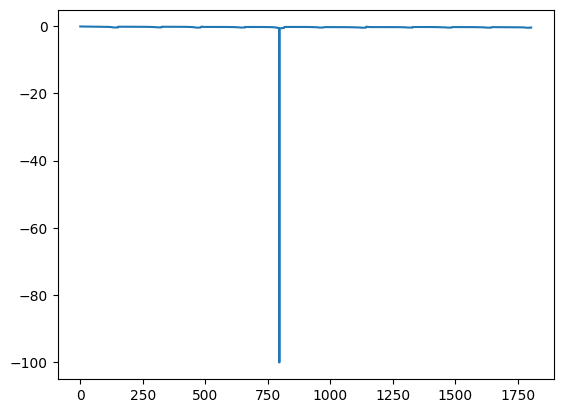

In [ ]:
plt.plot(np.array(reward_expected))

In [ ]:
from time import time

oracle = TwoEstimators(
    classifier=SuccessClassifier(), regressor=make_oracle_regressor()
)
oracle.fit(X, y)

all_solvers = solver_selector.solver_space.all_decisions_encoding
Xonline_features = Xonline[:, : -all_solvers.shape[1]]  # removing solvers encoding

regressor_online = TwoEstimators(
    classifier=SuccessClassifier(), regressor=RewardRegressor()
)
regressor_online.fit(Xoffline, yoffline)

data_incremental = []

for Xfeature in tqdm(Xonline_features):
    x_to_predict = stack_features_solvers(Xfeature, all_solvers)

    # online
    tpred = time()
    success_online, predictions_online = regressor_online.predict(x_to_predict)
    max_score_idx_online = np.argmax(predictions_online)
    tpred = time() - tpred

    # offline
    success_offline, predictions_offline = oracle.predict(x_to_predict)

    # feedback
    X_feedback = x_to_predict[max_score_idx_online].reshape(1, -1)
    y_feedback = predictions_offline[max_score_idx_online]
    tfeedback = time()
    regressor_online.partial_fit(X_feedback, [y_feedback])
    tfeedback = time() - tfeedback

    # saving stats
    data_incremental.append(
        {
            "ypred": predictions_online,
            "yoracle": predictions_offline,
            "tpred": tpred,
            "tfeedback": tfeedback,
        }
    )

100%|██████████| 1804/1804 [00:06<00:00, 288.92it/s]


In [ ]:
x_to_predict.shape

(1095, 36)

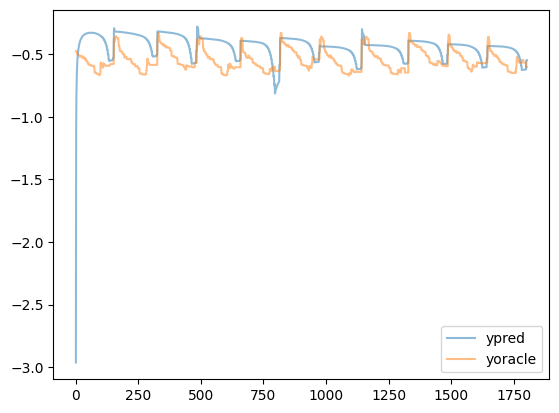

In [ ]:
plt.plot([max(x["ypred"]) for x in data_incremental], label="ypred", alpha=0.5)
plt.plot([max(x["yoracle"]) for x in data_incremental], label="yoracle", alpha=0.5)
# plt.ylim(-2, -1)
plt.legend()

4.12


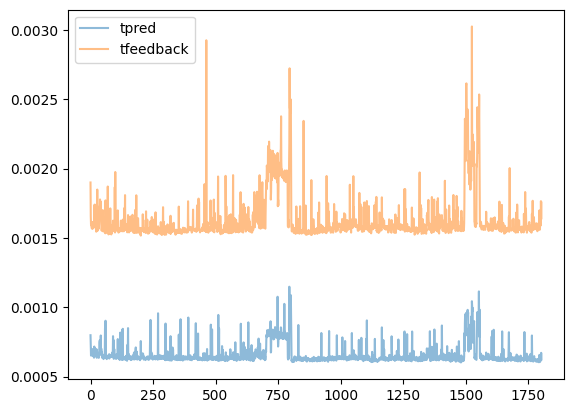

In [ ]:
tpred = np.array([(x["tpred"]) for x in data_incremental])
tfeedback = np.array([(x["tfeedback"]) for x in data_incremental])
plt.plot(tpred, label="tpred", alpha=0.5)
plt.plot(tfeedback, label="tfeedback", alpha=0.5)
plt.legend()
print(f'{np.sum(tpred) + np.sum(tfeedback):.2f}')

$R = -\log(T)$

$T = \exp(-R)$

In [ ]:
yoracle = np.array([max(x["yoracle"]) for x in data_incremental])
sim_time_oracle = np.sum(np.exp(-yoracle))
print(f'{sim_time_oracle / HOUR:.2f}')

0.87


In [ ]:
ypred = np.array([x['yoracle'][np.argmax(x["ypred"])] for x in data_incremental])
sim_time_pred = np.sum(np.exp(-ypred))
print(f'{sim_time_pred / HOUR:.2f}')
# plt.plot(np.exp(-ypred))

0.93


0.89


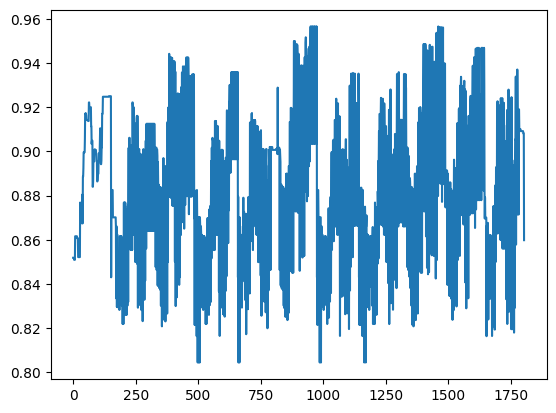

In [ ]:
ntf = [top_1_normalized_score(ypred=x['ypred'], ytrue=x['yoracle']) for x in data_incremental]
plt.plot(ntf)
mean_NTS = np.mean(ntf)
print(f'{mean_NTS:.2f}')

eps = 1e-02, mean_topeps = 0.00
eps = 2e-02, mean_topeps = 0.00
eps = 5e-02, mean_topeps = 0.34
eps = 1e-01, mean_topeps = 0.92
eps = 2e-01, mean_topeps = 1.00


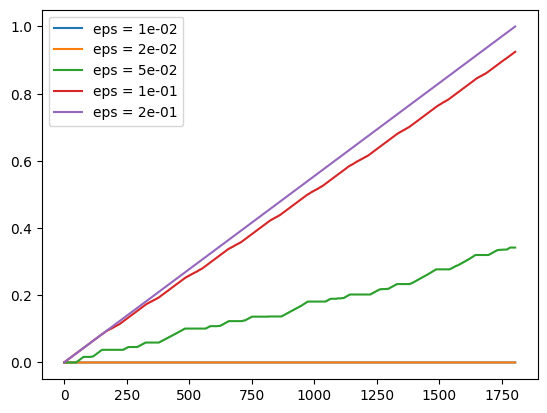

In [ ]:
for eps in [1e-2, 2e-2, 5e-2, 1e-1, 2e-1]:
    topeps = [top_eps_accuracy(ypred=x['ypred'], ytrue=x['yoracle'], eps=eps) for x in data_incremental]
    plt.plot(np.cumsum(topeps) / len(topeps), label=f'{eps = :.0e}')
    mean_topeps = np.mean(topeps)
    print(f'{eps = :.0e}, {mean_topeps = :.2f}')
plt.legend()
# plt.grid()

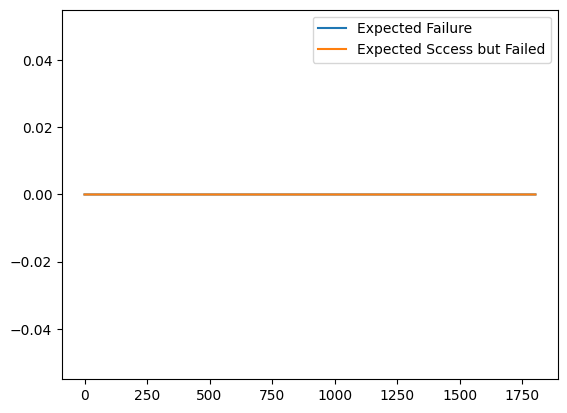

In [ ]:
ef = [max(x["yoracle"]) <= FAIL_REWARD for x in data_incremental]
esbf = [
    max(x["yoracle"]) > FAIL_REWARD
    and x["yoracle"][np.argmax(x["ypred"])] <= FAIL_REWARD
    for x in data_incremental
]
plt.plot(ef, label='Expected Failure')
plt.plot(esbf, label='Expected Sccess but Failed')
plt.legend()

Regret: 117.64466788958876


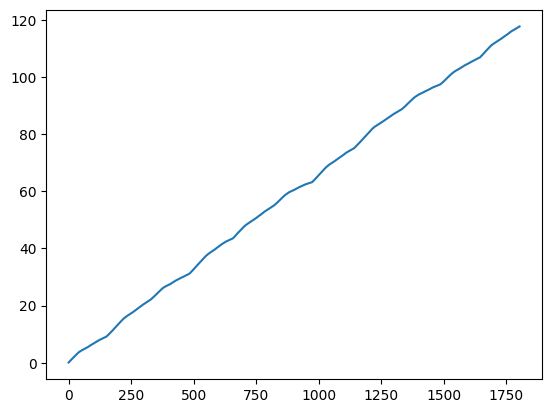

In [ ]:
regret = [max(x['yoracle']) - x["yoracle"][np.argmax(x["ypred"])] for x in data_incremental]
plt.plot(np.cumsum(regret))
print('Regret:', np.sum(regret))

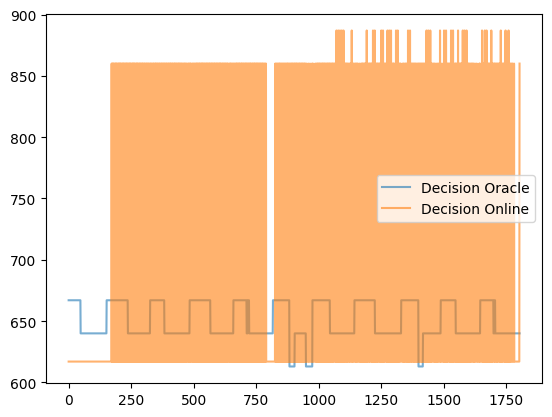

In [ ]:
plt.plot([np.argmax(x['yoracle']) for x in data_incremental], label='Decision Oracle', alpha=0.6)
plt.plot([np.argmax(x['ypred']) for x in data_incremental], label='Decision Online', alpha=0.6)
plt.legend()